<a href="https://colab.research.google.com/github/ashikeelahi3/Bioinformatics/blob/main/MRI%20Code%201.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install nibabel nilearn matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 64.9 MB/s eta 0:00:00


In [3]:
from google.colab import files
uploaded = files.upload()


Saving sub-control032014_task-resting_run-1_bold.nii.gz to sub-control032014_task-resting_run-1_bold.nii.gz


In [4]:
from google.colab import files
uploaded = files.upload()


Saving sub-control032014_T1w.svreg.label.nii.gz to sub-control032014_T1w.svreg.label.nii.gz


In [5]:
import nibabel as nib
from nilearn.input_data import NiftiLabelsMasker
import matplotlib.pyplot as plt

# Replace with actual filenames if different
bold_file = 'sub-control032014_task-resting_run-1_bold.nii.gz'
atlas_file = 'sub-control032014_T1w.svreg.label.nii.gz'

# Load the images
bold_img = nib.load(bold_file)
atlas_img = nib.load(atlas_file)


/tmp/ipython-input-2089238920.py:2: DeprecationWarning: The import path 'nilearn.input_data' is deprecated in version 0.9. Importing from 'nilearn.input_data' will be possible at least until release 0.13.0. Please import from 'nilearn.maskers' instead.
  from nilearn.input_data import NiftiLabelsMasker


/usr/local/lib/python3.12/dist-packages/sklearn/utils/_set_output.py:319: UserWarning: After resampling the label image to the data image, the following labels were removed: {np.int16(780), np.int16(2391)}. Label image only contains 293 labels (including background).
  data_to_wrap = f(self, X, *args, **kwargs)


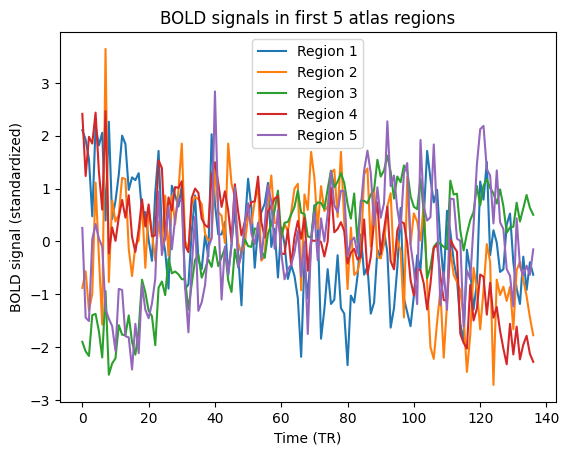

In [13]:
# Create masker to extract time series per atlas region
masker = NiftiLabelsMasker(labels_img=atlas_img, standardize=True)
time_series = masker.fit_transform(bold_img)

# Plot BOLD signal in the first 5 regions
plt.plot(time_series[:, :5])
plt.xlabel("Time (TR)")
plt.ylabel("BOLD signal (standardized)")
plt.title("BOLD signals in first 5 atlas regions")
plt.legend([f"Region {i+1}" for i in range(5)])
plt.show()


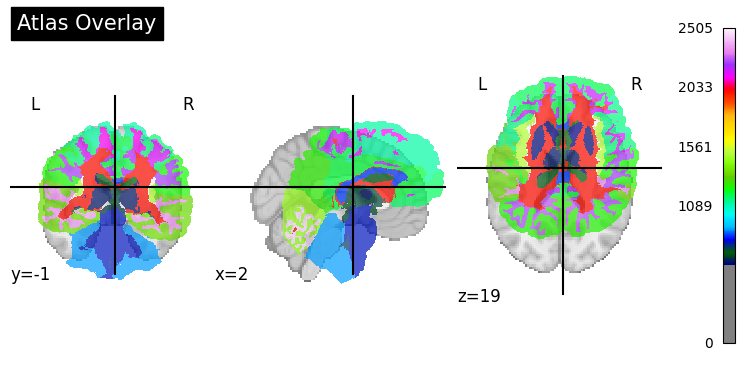

In [7]:
from nilearn import plotting

plotting.plot_roi(atlas_img, title="Atlas Overlay")


In [8]:
print("BOLD shape:", bold_img.shape)
print("Atlas shape:", atlas_img.shape)


BOLD shape: (64, 64, 27, 137)
Atlas shape: (175, 217, 203)


In [9]:
from nilearn.image import resample_to_img

# Resample atlas to match the BOLD image dimensions and affine
resampled_atlas_img = resample_to_img(source_img=atlas_img, target_img=bold_img, interpolation='nearest')


/tmp/ipython-input-2036970501.py:4: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  resampled_atlas_img = resample_to_img(source_img=atlas_img, target_img=bold_img, interpolation='nearest')
/tmp/ipython-input-2036970501.py:4: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  resampled_atlas_img = resample_to_img(source_img=atlas_img, target_img=bold_img, interpolation='nearest')


In [10]:
print("BOLD shape:", bold_img.shape)
print("Resampled atlas shape:", resampled_atlas_img.shape)


BOLD shape: (64, 64, 27, 137)
Resampled atlas shape: (64, 64, 27)


In [11]:
from nilearn.input_data import NiftiLabelsMasker

masker = NiftiLabelsMasker(labels_img=resampled_atlas_img, standardize=True)
time_series = masker.fit_transform(bold_img)

print("Time series shape:", time_series.shape)


Time series shape: (137, 292)


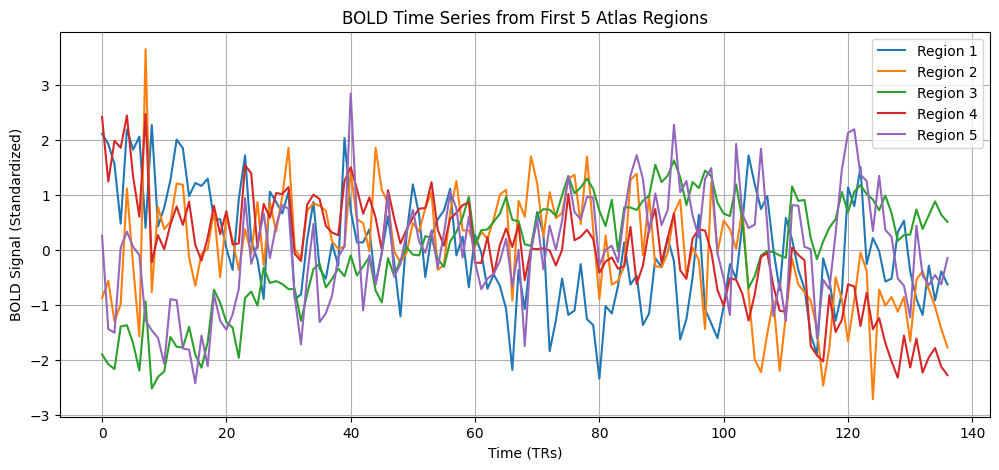

In [12]:
import matplotlib.pyplot as plt

# Plot BOLD signals from the first few atlas regions
plt.figure(figsize=(12, 5))
plt.plot(time_series[:, :5])
plt.xlabel("Time (TRs)")
plt.ylabel("BOLD Signal (Standardized)")
plt.title("BOLD Time Series from First 5 Atlas Regions")
plt.legend([f"Region {i+1}" for i in range(5)])
plt.grid(True)
plt.show()


In [16]:
from nilearn.input_data import NiftiLabelsMasker

masker = NiftiLabelsMasker(labels_img=resampled_atlas_img, standardize=True)
time_series = masker.fit_transform(bold_img)

print("Time series shape:", time_series.shape)


Time series shape: (137, 292)


In [17]:
from nilearn import image

# Extract the first volume (time index 0) for background display
bold_first_vol = image.index_img(bold_img, 0)


/tmp/ipython-input-1313795294.py:3: UserWarning: Casting data from int16 to float32
  plotting.plot_roi(roi_img=resampled_atlas_img,


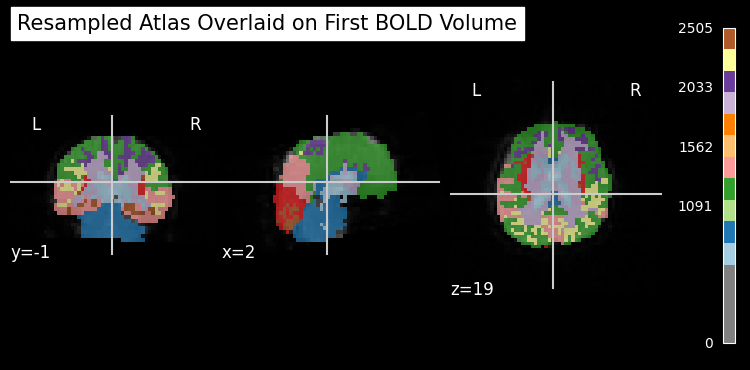

In [18]:
from nilearn import plotting

plotting.plot_roi(roi_img=resampled_atlas_img,
                  bg_img=bold_first_vol,
                  title="Resampled Atlas Overlaid on First BOLD Volume",
                  cmap='Paired',         # color map for atlas regions
                  display_mode='ortho',  # sagittal, coronal, axial
                  draw_cross=True)
plotting.show()


/tmp/ipython-input-777477594.py:1: UserWarning: Casting data from int16 to float32
  plotting.plot_roi(resampled_atlas_img,


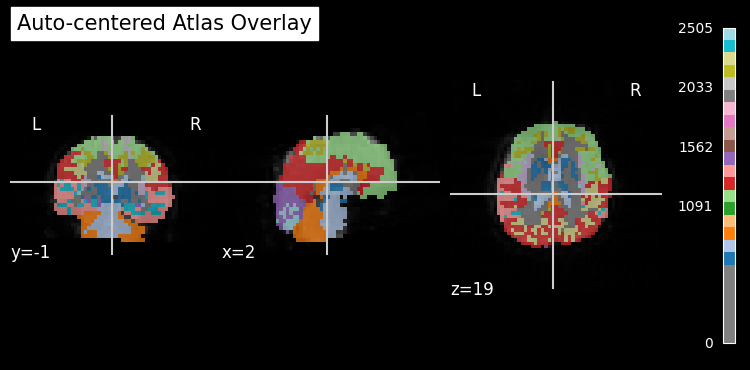

In [19]:
plotting.plot_roi(resampled_atlas_img,
                  bg_img=bold_first_vol,
                  title="Auto-centered Atlas Overlay",
                  cmap='tab20',
                  draw_cross=True)


/tmp/ipython-input-2830593371.py:1: UserWarning: Casting data from int16 to float32
  plotting.plot_roi(resampled_atlas_img,


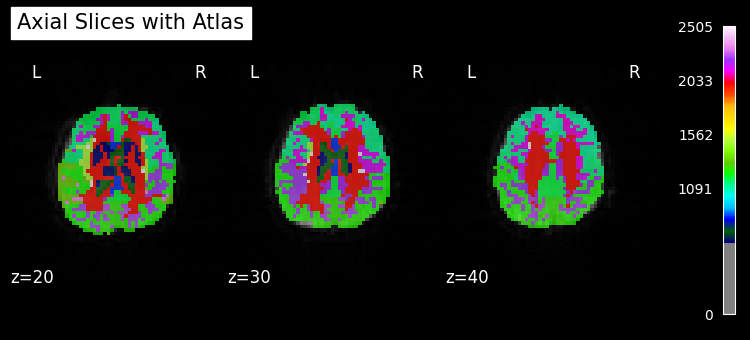

In [20]:
plotting.plot_roi(resampled_atlas_img,
                  bg_img=bold_first_vol,
                  display_mode='z',
                  cut_coords=[20, 30, 40],  # choose your z slices
                  title="Axial Slices with Atlas")


/tmp/ipython-input-2328114836.py:1: UserWarning: Casting data from int16 to float32
  plot = plotting.plot_roi(resampled_atlas_img,


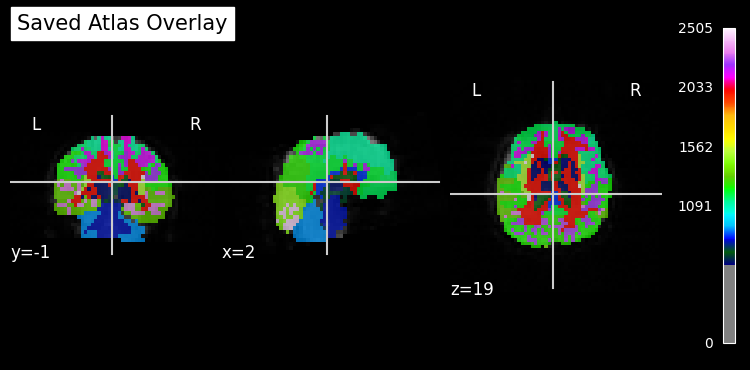

In [21]:
plot = plotting.plot_roi(resampled_atlas_img,
                         bg_img=bold_first_vol,
                         title="Saved Atlas Overlay",
                         draw_cross=True)
plot.savefig('atlas_overlay.png')


In [22]:
from google.colab import files
files.download('atlas_overlay.png')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>